# 09 — Análise Comparativa — Dataset Completo

Compara as 6 variantes no dataset completo (~20.639 tweets) e contrasta com os resultados do sample (500 tweets).

- Métrica principal: **F1-macro**
- Destaque para classes raras (`racism`, `misogyny`, `xenophobia`) com support adequado na base completa

In [1]:
import json
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score, confusion_matrix
)

CATEGORIAS = ["homophobia", "insult", "misogyny", "not_toxic", "obscene", "racism", "xenophobia"]

EXPERIMENTOS_CONFIG = {
    "zs_v1_base":         ("../results/full/zero_shot_v1_base.csv",        "ZS-v1 Base",         "zero_shot"),
    "zs_v2_descriptions": ("../results/full/zero_shot_v2_descriptions.csv", "ZS-v2 Descriptions", "zero_shot"),
    "zs_v3_no_antibias":  ("../results/full/zero_shot_v3_no_antibias.csv",  "ZS-v3 No-Antibias",  "zero_shot"),
    "fs_v1_1ex":          ("../results/full/few_shot_v1_1ex.csv",           "FS-v1 1-Example",    "few_shot"),
    "fs_v2_2ex_antibias": ("../results/full/few_shot_v2_2ex_antibias.csv",  "FS-v2 2ex+Antibias", "few_shot"),
    "fs_v3_2ex":          ("../results/full/few_shot_v3_2ex.csv",           "FS-v3 2-Examples",   "few_shot"),
}

CORES = {"zero_shot": "#4C72B0", "few_shot": "#DD8452"}

experimentos = {}
for chave, (path, label, grupo) in EXPERIMENTOS_CONFIG.items():
    if not Path(path).exists():
        print(f"[SKIP] {label} — arquivo não encontrado")
        continue
    df = pl.read_csv(path).with_columns(pl.col("predicao").str.to_lowercase())
    unknown = (df["predicao"] == "unknown").sum()
    print(f"{label:<22}: {len(df)} tweets | unknown={unknown}")
    experimentos[chave] = df

ZS-v1 Base            : 20813 tweets | unknown=2
ZS-v2 Descriptions    : 20813 tweets | unknown=0
ZS-v3 No-Antibias     : 20813 tweets | unknown=1
FS-v1 1-Example       : 20813 tweets | unknown=5
FS-v2 2ex+Antibias    : 20813 tweets | unknown=0
FS-v3 2-Examples      : 20813 tweets | unknown=2


## F1-macro por estratégia

In [2]:
metricas = {}

for chave, df in experimentos.items():
    _, label, grupo = EXPERIMENTOS_CONFIG[chave]
    y_true = df["label"].to_list()
    y_pred = df["predicao"].to_list()
    metricas[chave] = {
        "label": label,
        "grupo": grupo,
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted":     round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "precision_macro": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "recall_macro":    round(recall_score(y_true, y_pred,    average="macro", zero_division=0), 4),
        "per_class": {},
    }
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    for cat in CATEGORIAS:
        if cat in report:
            metricas[chave]["per_class"][cat] = {
                "f1":        round(report[cat]["f1-score"],  4),
                "precision": round(report[cat]["precision"], 4),
                "recall":    round(report[cat]["recall"],    4),
                "support":   int(report[cat]["support"]),
            }

print(f"{'Estratégia':<22} {'F1-macro':>10} {'F1-weighted':>12} {'Precision':>10} {'Recall':>8}")
print("-" * 66)
for chave, m in metricas.items():
    print(f"{m['label']:<22} {m['f1_macro']:>10.4f} {m['f1_weighted']:>12.4f} {m['precision_macro']:>10.4f} {m['recall_macro']:>8.4f}")

Estratégia               F1-macro  F1-weighted  Precision   Recall
------------------------------------------------------------------
ZS-v1 Base                 0.2238       0.7501     0.2327   0.2890
ZS-v2 Descriptions         0.2875       0.7240     0.2900   0.3936
ZS-v3 No-Antibias          0.2206       0.7376     0.2286   0.3409
FS-v1 1-Example            0.2706       0.7547     0.2592   0.4025
FS-v2 2ex+Antibias         0.3173       0.7666     0.3133   0.4473
FS-v3 2-Examples           0.2747       0.7659     0.2688   0.4112


## Ranking por F1-macro

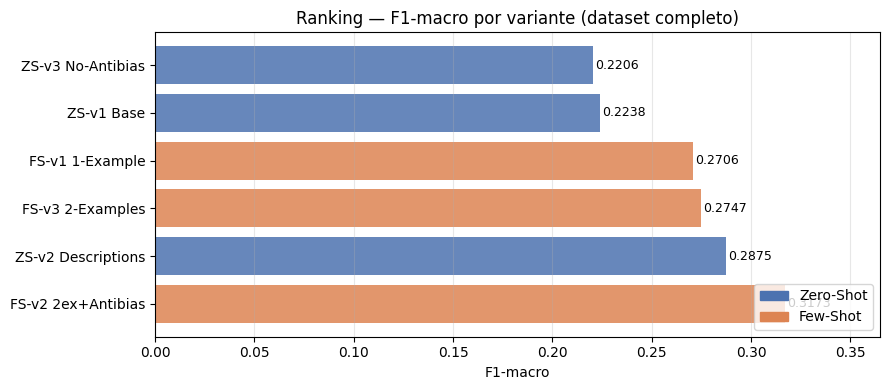


Melhor variante: FS-v2 2ex+Antibias — F1-macro=0.3173


In [3]:
if len(metricas) < 2:
    print("Menos de 2 variantes disponíveis — pulando gráfico de ranking.")
else:
    ranking = sorted(metricas.items(), key=lambda x: x[1]["f1_macro"], reverse=True)

    fig, ax = plt.subplots(figsize=(9, 4))
    labels_r = [m["label"] for _, m in ranking]
    f1s_r    = [m["f1_macro"] for _, m in ranking]
    cores_r  = [CORES[m["grupo"]] for _, m in ranking]

    bars = ax.barh(labels_r, f1s_r, color=cores_r, alpha=0.85)
    for bar, val in zip(bars, f1s_r):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel("F1-macro")
    ax.set_title("Ranking — F1-macro por variante (dataset completo)")
    ax.set_xlim(0, max(f1s_r) * 1.15)
    ax.grid(axis="x", alpha=0.3)
    legend = [
        mpatches.Patch(color=CORES["zero_shot"], label="Zero-Shot"),
        mpatches.Patch(color=CORES["few_shot"],  label="Few-Shot"),
    ]
    ax.legend(handles=legend, loc="lower right")
    plt.tight_layout()
    plt.savefig("../results/full/ranking_f1_macro.png", dpi=150)
    plt.show()

    melhor_chave, melhor_m = ranking[0]
    print(f"\nMelhor variante: {melhor_m['label']} — F1-macro={melhor_m['f1_macro']:.4f}")

## F1 por categoria — todas as variantes

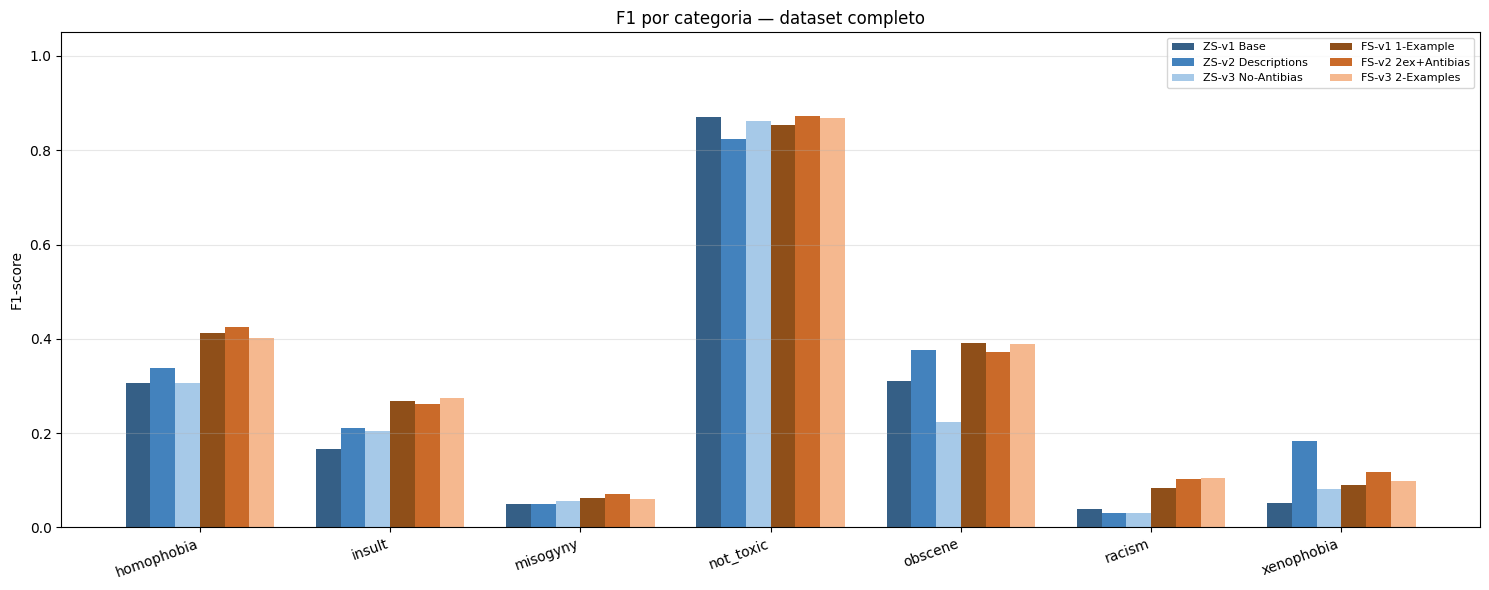

In [4]:
if len(metricas) < 2:
    print("Menos de 2 variantes disponíveis — pulando gráfico por categoria.")
else:
    fig, ax = plt.subplots(figsize=(15, 6))
    n = len(metricas)
    x = np.arange(len(CATEGORIAS))
    width = 0.13
    paleta_zs = ["#1f4e79", "#2e75b6", "#9dc3e6"]
    paleta_fs = ["#833c00", "#c55a11", "#f4b183"]
    palettas  = (paleta_zs + paleta_fs)[:n]

    for idx, (chave, m) in enumerate(metricas.items()):
        f1s = [m["per_class"].get(cat, {}).get("f1", 0) for cat in CATEGORIAS]
        offset = (idx - n / 2 + 0.5) * width
        ax.bar(x + offset, f1s, width, label=m["label"], color=palettas[idx], alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIAS, rotation=20, ha="right")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title("F1 por categoria — dataset completo")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../results/full/f1_por_categoria.png", dpi=150)
    plt.show()

## Matrizes de confusão — todas as variantes

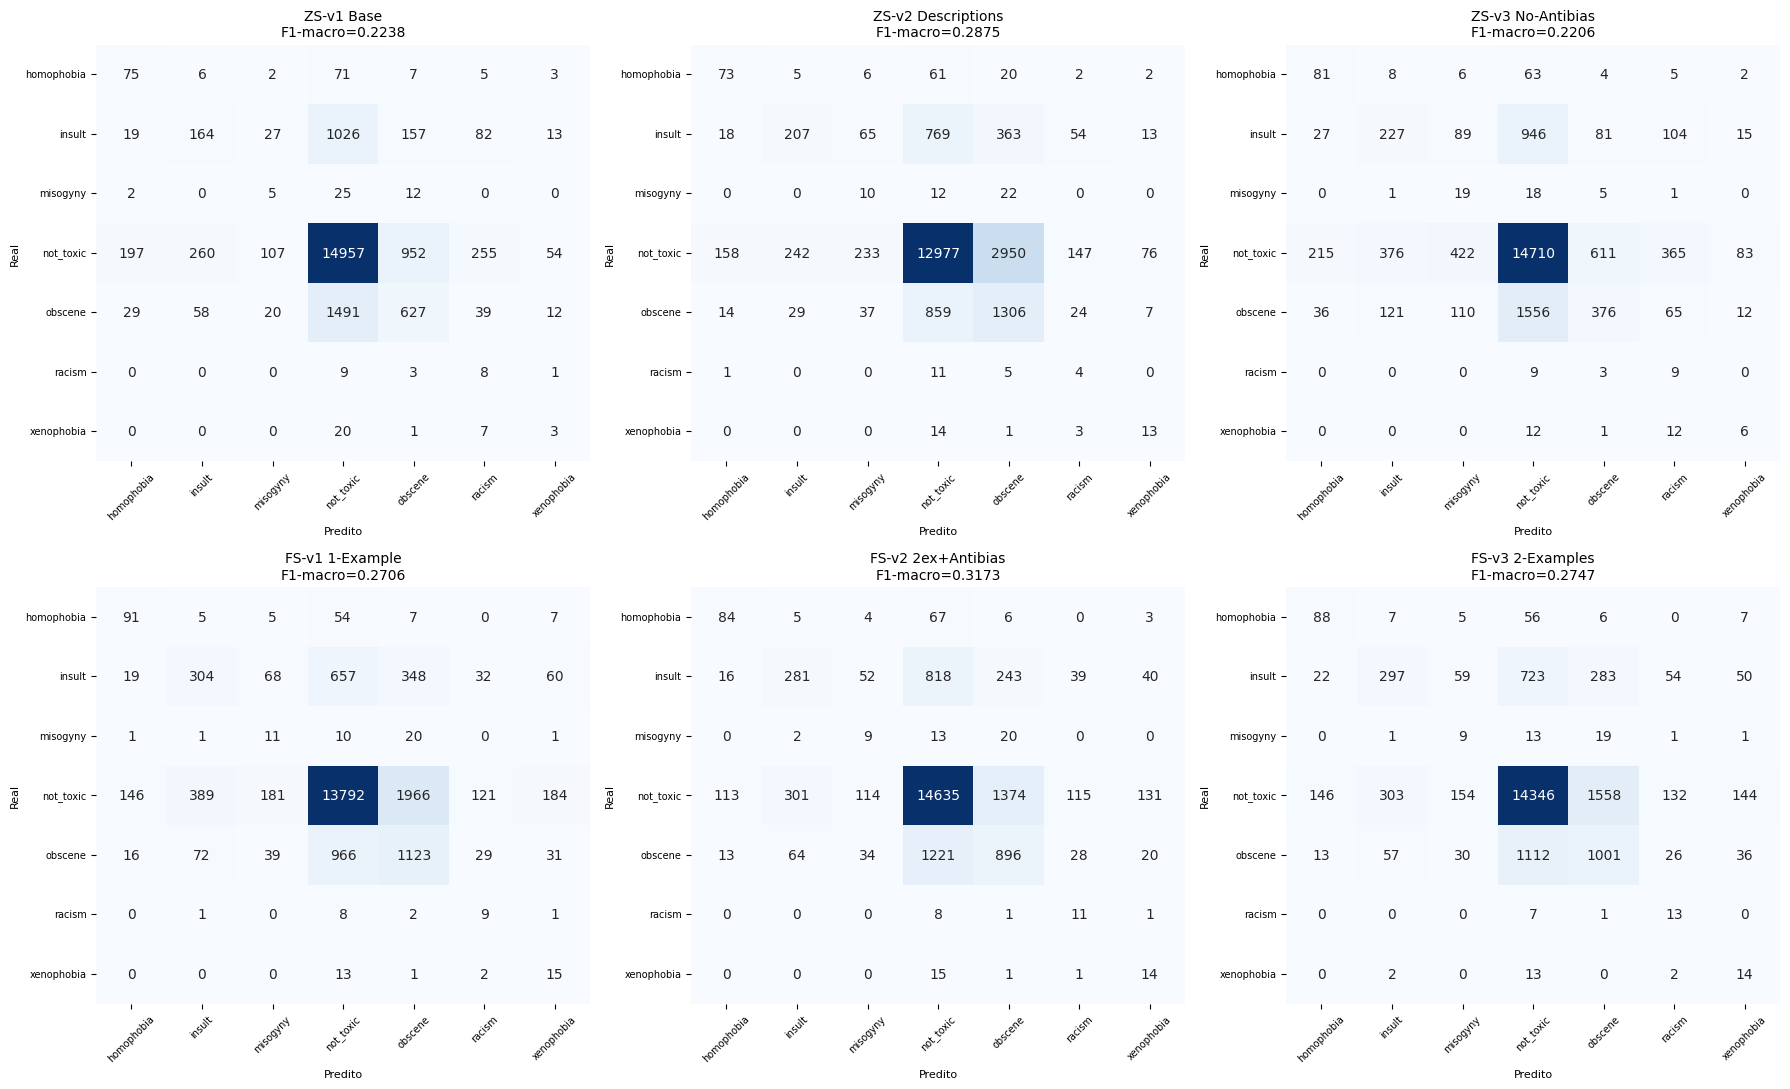

In [5]:
if len(experimentos) < 2:
    print("Menos de 2 variantes disponíveis — pulando matrizes de confusão.")
else:
    n_disp = len(experimentos)
    ncols = min(3, n_disp)
    nrows = (n_disp + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows))
    axes_flat = np.array(axes).flatten()

    for ax, (chave, df) in zip(axes_flat, experimentos.items()):
        m = metricas[chave]
        y_true = df["label"].to_list()
        y_pred = df["predicao"].to_list()
        cm = confusion_matrix(y_true, y_pred, labels=CATEGORIAS)
        sns.heatmap(cm, annot=True, fmt="d",
                    xticklabels=CATEGORIAS, yticklabels=CATEGORIAS,
                    cmap="Blues", ax=ax, cbar=False)
        ax.set_xlabel("Predito", fontsize=8)
        ax.set_ylabel("Real", fontsize=8)
        ax.set_title(f"{m['label']}\nF1-macro={m['f1_macro']:.4f}", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", rotation=0,  labelsize=7)

    for ax in axes_flat[n_disp:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig("../results/full/confusion_matrices.png", dpi=150)
    plt.show()

## Comparação: Sample (500) vs Full (~20.639)

In [6]:
sample_path = "../results/metrics_summary.json"
if not Path(sample_path).exists():
    print("[SKIP] results/metrics_summary.json não encontrado — execute 06_results_analysis.ipynb primeiro.")
else:
    sample_summary = json.load(open(sample_path, encoding="utf-8"))

    print(f"{'Variante':<22} {'Sample F1':>10} {'Full F1':>10} {'Δ':>8}")
    print("-" * 54)
    for chave, m_full in metricas.items():
        m_sample = sample_summary.get(chave, {})
        f1_sample = m_sample.get("f1_macro", float("nan"))
        f1_full   = m_full["f1_macro"]
        delta = f1_full - f1_sample
        sign = "+" if delta >= 0 else ""
        print(f"{m_full['label']:<22} {f1_sample:>10.4f} {f1_full:>10.4f} {sign}{delta:>7.4f}")

    print("\n--- F1 por classe (variantes disponíveis) ---")
    for chave, m_full in metricas.items():
        m_sample = sample_summary.get(chave, {})
        if not m_sample:
            continue
        print(f"\n{m_full['label']}")
        print(f"  {'Classe':<14} {'Sample':>8} {'Full':>8} {'Δ':>8} {'Sup.Full':>10}")
        print("  " + "-" * 44)
        for cat in CATEGORIAS:
            f1_s = m_sample.get("per_class", {}).get(cat, {}).get("f1", 0.0)
            f1_f = m_full["per_class"].get(cat, {}).get("f1", 0.0)
            sup  = m_full["per_class"].get(cat, {}).get("support", 0)
            delta = round(f1_f - f1_s, 4)
            sign = "+" if delta >= 0 else ""
            print(f"  {cat:<14} {f1_s:>8.4f} {f1_f:>8.4f} {sign}{delta:>7.4f} {sup:>10}")

Variante                Sample F1    Full F1        Δ
------------------------------------------------------
ZS-v1 Base                 0.2347     0.2238 -0.0109
ZS-v2 Descriptions         0.2673     0.2875 + 0.0202
ZS-v3 No-Antibias          0.2516     0.2206 -0.0310
FS-v1 1-Example            0.2994     0.2706 -0.0288
FS-v2 2ex+Antibias         0.2750     0.3173 + 0.0423
FS-v3 2-Examples           0.2606     0.2747 + 0.0141

--- F1 por classe (variantes disponíveis) ---

ZS-v1 Base
  Classe           Sample     Full        Δ   Sup.Full
  --------------------------------------------
  homophobia       0.4444   0.3055 -0.1389        169
  insult           0.0870   0.1659 + 0.0789       1489
  misogyny         0.0000   0.0488 + 0.0488         44
  not_toxic        0.8616   0.8700 + 0.0084      16783
  obscene          0.2500   0.3108 + 0.0608       2276
  racism           0.0000   0.0384 + 0.0384         21
  xenophobia       0.0000   0.0513 + 0.0513         31

ZS-v2 Descriptions
  Cla

## Classes raras — análise detalhada

In [7]:
RARAS = ["racism", "misogyny", "xenophobia", "homophobia"]

print(f"{'Variante':<22}", end="")
for cat in RARAS:
    print(f" {cat:>12}", end="")
print()
print("-" * (22 + 13 * len(RARAS)))

for chave, m in metricas.items():
    print(f"{m['label']:<22}", end="")
    for cat in RARAS:
        f1 = m["per_class"].get(cat, {}).get("f1", 0.0)
        sup = m["per_class"].get(cat, {}).get("support", 0)
        print(f" {f1:>6.3f}({sup:>4})", end="")
    print()

Variante                     racism     misogyny   xenophobia   homophobia
--------------------------------------------------------------------------
ZS-v1 Base              0.038(  21)  0.049(  44)  0.051(  31)  0.305( 169)
ZS-v2 Descriptions      0.031(  21)  0.051(  44)  0.183(  31)  0.337( 169)
ZS-v3 No-Antibias       0.031(  21)  0.055(  44)  0.081(  31)  0.307( 169)
FS-v1 1-Example         0.084(  21)  0.063(  44)  0.091(  31)  0.412( 169)
FS-v2 2ex+Antibias      0.102(  21)  0.070(  44)  0.117(  31)  0.425( 169)
FS-v3 2-Examples        0.104(  21)  0.060(  44)  0.099(  31)  0.402( 169)


## Salvar resultados

In [8]:
with open("../results/full/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)
print("Salvo: results/full/metrics_summary.json")

rows = []
for chave, m in metricas.items():
    for cat in CATEGORIAS:
        pc = m["per_class"].get(cat, {})
        rows.append({
            "estrategia": chave, "label": m["label"], "grupo": m["grupo"],
            "categoria": cat,
            "f1": pc.get("f1", 0.0), "precision": pc.get("precision", 0.0),
            "recall": pc.get("recall", 0.0), "support": pc.get("support", 0),
            "f1_macro": m["f1_macro"], "f1_weighted": m["f1_weighted"],
        })
pl.DataFrame(rows).write_csv("../results/full/metrics_per_strategy.csv")
print("Salvo: results/full/metrics_per_strategy.csv")

print("\nRESUMO FINAL — ranking por F1-macro (dataset completo)")
print("=" * 55)
for chave, m in sorted(metricas.items(), key=lambda x: x[1]["f1_macro"], reverse=True):
    print(f"{m['label']:<22}  F1-macro={m['f1_macro']:.4f}  F1-weighted={m['f1_weighted']:.4f}")

Salvo: results/full/metrics_summary.json
Salvo: results/full/metrics_per_strategy.csv

RESUMO FINAL — ranking por F1-macro (dataset completo)
FS-v2 2ex+Antibias      F1-macro=0.3173  F1-weighted=0.7666
ZS-v2 Descriptions      F1-macro=0.2875  F1-weighted=0.7240
FS-v3 2-Examples        F1-macro=0.2747  F1-weighted=0.7659
FS-v1 1-Example         F1-macro=0.2706  F1-weighted=0.7547
ZS-v1 Base              F1-macro=0.2238  F1-weighted=0.7501
ZS-v3 No-Antibias       F1-macro=0.2206  F1-weighted=0.7376
